<a href="https://colab.research.google.com/github/sabinrajpokhrel/Wildfire_ML_Project/blob/main/Wildfire_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wildfire Risk Prediction Model for Nepal

## Machine Learning Model Development

This notebook develops and evaluates a machine-learning model for predicting
next-day satellite fire-hotspot risk across Nepal.

The modelling dataset was previously constructed by combining:

- ERA5-Land daily environmental data
- NASA FIRMS active-fire detections
- Spatial matching between FIRMS points and ERA5 grid cells
- Daily fire labels for each geographic grid cell

The objective of this notebook is to use current and recent environmental
conditions to predict whether NASA FIRMS will detect an active-fire hotspot
in the same grid cell on the following day.

## 1. Environment Setup

In [ ]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
PROJECT_FOLDER = Path(
    "/content/drive/MyDrive/Wildfire_ML_Project"
)

MODEL_FOLDER = PROJECT_FOLDER / "models"
RESULTS_FOLDER = PROJECT_FOLDER / "results"

MODEL_FOLDER.mkdir(parents=True, exist_ok=True)
RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)

BASE_DATASET_PATH = (
    PROJECT_FOLDER
    / "wildfire_base_grid_daily_same_day.parquet"
)

print("Project folder:", PROJECT_FOLDER)
print("Base dataset:", BASE_DATASET_PATH)

Project folder: /content/drive/MyDrive/Wildfire_ML_Project
Base dataset: /content/drive/MyDrive/Wildfire_ML_Project/wildfire_base_grid_daily_same_day.parquet


## 2. Load the Labelled Base Dataset

The base dataset contains one row for every ERA5 grid cell and date.

Each row includes:

- Geographic coordinates
- Daily weather variables
- NASA FIRMS fire-detection label for the same day
- Aggregated fire metadata for analysis

The same-day fire label will be shifted by one day to create a predictive
next-day target.

In [ ]:
wildfire = pd.read_parquet(
    BASE_DATASET_PATH
)

wildfire["date"] = pd.to_datetime(
    wildfire["date"],
    errors="coerce"
)

wildfire = (
    wildfire
    .sort_values(
        ["latitude", "longitude", "date"]
    )
    .reset_index(drop=True)
)

print("Dataset loaded successfully.")
print("Shape:", wildfire.shape)

Dataset loaded successfully.
Shape: (680500, 20)


In [ ]:
print(
    "Date range:",
    wildfire["date"].min(),
    "to",
    wildfire["date"].max()
)

print(
    "Unique dates:",
    wildfire["date"].nunique()
)

print(
    "Unique grid cells:",
    wildfire[
        ["latitude", "longitude"]
    ].drop_duplicates().shape[0]
)

print(
    "Duplicate grid-cell dates:",
    wildfire.duplicated(
        ["date", "latitude", "longitude"]
    ).sum()
)

print(
    "Missing values:",
    wildfire.isna().sum().sum()
)

print(
    "Same-day fire-labelled rows:",
    wildfire["fire_detected"].sum()
)

Date range: 2025-01-05 00:00:00 to 2026-05-19 00:00:00
Unique dates: 500
Unique grid cells: 1361
Duplicate grid-cell dates: 0
Missing values: 0
Same-day fire-labelled rows: 2260


In [ ]:
column_summary = pd.DataFrame({
    "column": wildfire.columns,
    "dtype": wildfire.dtypes.astype(str).values,
    "missing": wildfire.isna().sum().values
})

column_summary

,column,dtype,missing
0,date,datetime64[ns],0
1,latitude,float64,0
2,longitude,float64,0
3,temperature_mean_c,float64,0
4,temperature_max_c,float64,0
5,dewpoint_c,float64,0
6,relative_humidity,float64,0
7,u_wind_mps,float64,0
8,v_wind_mps,float64,0
9,wind_speed_mps,float64,0


## 3. Next-Day Target Construction

The existing `fire_detected` field indicates whether a hotspot was recorded
on the same date as the weather observations.

For early-warning prediction, the target is shifted one day backward within
each geographic grid cell:

- Input features: weather conditions on day `t`
- Target: fire detection on day `t + 1`

The resulting target is named `fire_next_day`.

In [ ]:
wildfire["fire_next_day"] = (
    wildfire
    .groupby(
        ["latitude", "longitude"]
    )["fire_detected"]
    .shift(-1)
)

In [ ]:
rows_before = len(wildfire)

wildfire = wildfire.dropna(
    subset=["fire_next_day"]
).copy()

wildfire["fire_next_day"] = (
    wildfire["fire_next_day"]
    .astype("int8")
)

rows_removed = rows_before - len(wildfire)

print("Rows removed without next-day labels:", rows_removed)
print("Remaining rows:", len(wildfire))

Rows removed without next-day labels: 1361
Remaining rows: 679139


In [ ]:
target_counts = (
    wildfire["fire_next_day"]
    .value_counts()
    .reindex([0, 1], fill_value=0)
)

target_summary = pd.DataFrame({
    "target": [
        "No hotspot next day",
        "Hotspot next day"
    ],
    "rows": target_counts.values,
    "percentage": (
        target_counts.values
        / len(wildfire)
        * 100
    )
})

target_summary

,target,rows,percentage
0,No hotspot next day,676879,99.667226
1,Hotspot next day,2260,0.332774


In [ ]:
print(
    "Modelling date range:",
    wildfire["date"].min(),
    "to",
    wildfire["date"].max()
)

print(
    "Positive next-day examples:",
    wildfire["fire_next_day"].sum()
)

Modelling date range: 2025-01-05 00:00:00 to 2026-05-18 00:00:00
Positive next-day examples: 2260


## 4. Feature Engineering

Wildfire occurrence is influenced not only by weather conditions on a single
day, but also by environmental conditions accumulated over several preceding
days.

Rolling features are therefore created separately for every ERA5 grid cell.
These include recent rainfall, humidity, maximum temperature, wind speed and
soil moisture.

Calendar and seasonal variables are also created to allow the model to learn
Nepal's annual wildfire pattern.

In [ ]:
GROUP_COLUMNS = [
    "latitude",
    "longitude"
]

wildfire = (
    wildfire
    .sort_values(
        GROUP_COLUMNS + ["date"]
    )
    .reset_index(drop=True)
)

print("Dataset sorted successfully.")

Dataset sorted successfully.


In [ ]:
# Low rainfall values indicate prolonged dry conditions.
for window in [3, 7, 14]:
    wildfire[f"rainfall_sum_{window}d"] = (
        wildfire
        .groupby(GROUP_COLUMNS)["precipitation_mm"]
        .transform(
            lambda values, w=window:
            values.rolling(
                window=w,
                min_periods=1
            ).sum()
        )
    )

In [ ]:
# Lower recent humidity generally represents drier atmospheric conditions.
for window in [3, 7]:
    wildfire[f"humidity_mean_{window}d"] = (
        wildfire
        .groupby(GROUP_COLUMNS)["relative_humidity"]
        .transform(
            lambda values, w=window:
            values.rolling(
                window=w,
                min_periods=1
            ).mean()
        )
    )

In [ ]:
# captures recent heat events that may increase vegetation and fuel dryness.
for window in [3, 7]:
    wildfire[f"temperature_max_{window}d"] = (
        wildfire
        .groupby(GROUP_COLUMNS)["temperature_max_c"]
        .transform(
            lambda values, w=window:
            values.rolling(
                window=w,
                min_periods=1
            ).max()
        )
    )

In [ ]:
# 3 day mean (wind speed)
wildfire["wind_speed_max_3d"] = (
    wildfire
    .groupby(GROUP_COLUMNS)["wind_speed_mps"]
    .transform(
        lambda values:
        values.rolling(
            window=3,
            min_periods=1
        ).max()
    )
)

In [ ]:
# 7 day mean (wind speed)
wildfire["wind_speed_mean_7d"] = (
    wildfire
    .groupby(GROUP_COLUMNS)["wind_speed_mps"]
    .transform(
        lambda values:
        values.rolling(
            window=7,
            min_periods=1
        ).mean()
    )
)

In [ ]:
# Lower soil moisture can act as a proxy for dry surface and fuel conditions.
wildfire["soil_moisture_mean_7d"] = (
    wildfire
    .groupby(GROUP_COLUMNS)["soil_moisture"]
    .transform(
        lambda values:
        values.rolling(
            window=7,
            min_periods=1
        ).mean()
    )
)

In [ ]:
# A dry day = Daily precipitation below 1 millimetre

DRY_DAY_THRESHOLD_MM = 1.0

def calculate_consecutive_dry_days(
    precipitation_series,
    threshold=DRY_DAY_THRESHOLD_MM
):
    dry_day = precipitation_series < threshold

    # Every wet day starts a new group.
    reset_group = (~dry_day).cumsum()

    consecutive_days = (
        dry_day
        .groupby(reset_group)
        .cumsum()
    )

    return consecutive_days.astype("int16")

In [ ]:
wildfire["consecutive_dry_days"] = (
    wildfire
    .groupby(
        GROUP_COLUMNS,
        group_keys=False
    )["precipitation_mm"]
    .transform(calculate_consecutive_dry_days)
)

In [ ]:
wildfire[
    [
        "date",
        "latitude",
        "longitude",
        "precipitation_mm",
        "consecutive_dry_days"
    ]
].head(10)

,date,latitude,longitude,precipitation_mm,consecutive_dry_days
0,2025-01-05,26.399709,87.301223,0.000000,1
1,2025-01-06,26.399709,87.301223,0.000862,2
2,2025-01-07,26.399709,87.301223,0.016232,3
3,2025-01-08,26.399709,87.301223,0.018674,4
4,2025-01-09,26.399709,87.301223,0.001863,5
5,2025-01-10,26.399709,87.301223,0.002151,6
6,2025-01-11,26.399709,87.301223,0.000852,7
7,2025-01-12,26.399709,87.301223,0.025243,8
8,2025-01-13,26.399709,87.301223,0.263956,9
9,2025-01-14,26.399709,87.301223,0.001276,10


In [ ]:
# Month provides a basic seasonal indicator.
wildfire["month"] = (
    wildfire["date"]
    .dt.month
    .astype("int8")
)

wildfire["day_of_year"] = (
    wildfire["date"]
    .dt.dayofyear
    .astype("int16")
)

In [ ]:
# December and January are consecutive months, but raw month numbers represent them as far apart. Cyclical variables solve this problem.
# These allow the model to represent the annual seasonal cycle continuously.
wildfire["day_of_year_sin"] = np.sin(
    2 * np.pi
    * wildfire["day_of_year"]
    / 365.25
)

wildfire["day_of_year_cos"] = np.cos(
    2 * np.pi
    * wildfire["day_of_year"]
    / 365.25
)

In [ ]:
def assign_nepal_season(month):
    if month in [12, 1, 2]:
        return "winter"

    if month in [3, 4, 5]:
        return "pre_monsoon"

    if month in [6, 7, 8, 9]:
        return "monsoon"

    return "post_monsoon"

In [ ]:
wildfire["season"] = (
    wildfire["month"]
    .apply(assign_nepal_season)
)

In [ ]:
season_dummies = pd.get_dummies(
    wildfire["season"],
    prefix="season",
    dtype="int8"
)

wildfire = pd.concat(
    [
        wildfire.drop(columns=["season"]),
        season_dummies
    ],
    axis=1
)

In [ ]:
ENGINEERED_FEATURES = [
    "rainfall_sum_3d",
    "rainfall_sum_7d",
    "rainfall_sum_14d",
    "humidity_mean_3d",
    "humidity_mean_7d",
    "temperature_max_3d",
    "temperature_max_7d",
    "wind_speed_max_3d",
    "wind_speed_mean_7d",
    "soil_moisture_mean_7d",
    "consecutive_dry_days",
    "month",
    "day_of_year",
    "day_of_year_sin",
    "day_of_year_cos"
]

print(
    "Missing engineered values:",
    wildfire[ENGINEERED_FEATURES]
    .isna()
    .sum()
    .sum()
)

print(
    "Dataset shape after feature engineering:",
    wildfire.shape
)

Missing engineered values: 0
Dataset shape after feature engineering: (679139, 40)


In [ ]:
wildfire[
    [
        "date",
        "latitude",
        "longitude",
        "temperature_mean_c",
        "relative_humidity",
        "precipitation_mm",
        "rainfall_sum_7d",
        "humidity_mean_7d",
        "temperature_max_7d",
        "consecutive_dry_days",
        "fire_next_day"
    ]
].head()

,date,latitude,longitude,temperature_mean_c,relative_humidity,precipitation_mm,rainfall_sum_7d,humidity_mean_7d,temperature_max_7d,consecutive_dry_days,fire_next_day
0,2025-01-05,26.399709,87.301223,18.407688,67.685346,0.000000,0.000000,67.685346,24.489526,1,0
1,2025-01-06,26.399709,87.301223,18.803619,63.838455,0.000862,0.000862,65.761900,24.489526,2,0
2,2025-01-07,26.399709,87.301223,17.977756,71.270197,0.016232,0.017095,67.597999,24.489526,3,0
3,2025-01-08,26.399709,87.301223,15.343290,74.953143,0.018674,0.035769,69.436785,24.489526,4,0
4,2025-01-09,26.399709,87.301223,15.096641,75.012800,0.001863,0.037632,70.551988,24.489526,5,0


## 5. Target-Leakage Prevention

Target leakage occurs when model inputs contain information that would not be
available at the time of prediction.

FIRMS-derived variables such as fire count, Fire Radiative Power, brightness
and confidence directly describe an observed fire event. Including these
variables would allow the model to indirectly see the answer it is expected
to predict.

These columns are retained for analysis but excluded from the model feature
matrix.

In [ ]:
LEAKAGE_COLUMNS = [
    "fire_detected",
    "fire_next_day",
    "fire_count",
    "frp_sum",
    "frp_max",
    "confidence_mean",
    "brightness_mean",
    "match_distance_mean_km",
    "match_distance_max_km"
]

In [ ]:
NON_MODEL_COLUMNS = [
    "date"
]

In [ ]:
MODEL_FEATURES = [
    # Geographic features
    "latitude",
    "longitude",

    # Current-day weather
    "temperature_mean_c",
    "temperature_max_c",
    "dewpoint_c",
    "relative_humidity",
    "u_wind_mps",
    "v_wind_mps",
    "wind_speed_mps",
    "precipitation_mm",
    "soil_moisture",

    # Recent weather history
    "rainfall_sum_3d",
    "rainfall_sum_7d",
    "rainfall_sum_14d",
    "humidity_mean_3d",
    "humidity_mean_7d",
    "temperature_max_3d",
    "temperature_max_7d",
    "wind_speed_max_3d",
    "wind_speed_mean_7d",
    "soil_moisture_mean_7d",
    "consecutive_dry_days",

    # Seasonal information
    "month",
    "day_of_year_sin",
    "day_of_year_cos"
]

In [ ]:
SEASON_COLUMNS = [
    column
    for column in wildfire.columns
    if column.startswith("season_")
]

MODEL_FEATURES.extend(SEASON_COLUMNS)

In [ ]:
MODEL_FEATURES = list(
    dict.fromkeys(MODEL_FEATURES)
)

In [ ]:
leakage_in_features = (
    set(MODEL_FEATURES)
    .intersection(LEAKAGE_COLUMNS)
)

assert not leakage_in_features, (
    f"Target leakage detected: {leakage_in_features}"
)

print("No leakage columns are present in MODEL_FEATURES.")
print("Number of model features:", len(MODEL_FEATURES))

No leakage columns are present in MODEL_FEATURES.
Number of model features: 29


In [ ]:
# Creating feature matrix and target
X = wildfire[MODEL_FEATURES].copy()

y = wildfire["fire_next_day"].copy()

In [ ]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print(
    "Missing model feature values:",
    X.isna().sum().sum()
)

print(
    "Positive target examples:",
    y.sum()
)

print(
    "Positive target percentage:",
    round(
        y.mean() * 100,
        4
    ),
    "%"
)

Feature matrix shape: (679139, 29)
Target shape: (679139,)
Missing model feature values: 0
Positive target examples: 2260
Positive target percentage: 0.3328 %


In [ ]:
MODEL_READY_PATH = (
    PROJECT_FOLDER
    / "wildfire_feature_engineered_next_day.parquet"
)

wildfire.to_parquet(
    MODEL_READY_PATH,
    index=False
)

print(
    "Saved feature-engineered dataset:",
    MODEL_READY_PATH
)

Saved feature-engineered dataset: /content/drive/MyDrive/Wildfire_ML_Project/wildfire_feature_engineered_next_day.parquet


## 6. Chronological Data Splitting

The dataset contains spatial observations collected over time. A random split
could place future observations in the training set and earlier observations
in the test set, producing an unrealistic evaluation.

The data is therefore divided chronologically:

- Training: 5 January 2025 to 31 December 2025
- Validation: 1 January 2026 to 28 February 2026
- Testing: 1 March 2026 to 18 May 2026

The validation set is used for model and probability-threshold selection.
The test set is used only for the final unbiased evaluation.

In [ ]:
TRAIN_END = pd.Timestamp("2025-12-31")
VALIDATION_START = pd.Timestamp("2026-01-01")
VALIDATION_END = pd.Timestamp("2026-02-28")
TEST_START = pd.Timestamp("2026-03-01")

train_mask = wildfire["date"] <= TRAIN_END

validation_mask = (
    wildfire["date"].between(
        VALIDATION_START,
        VALIDATION_END
    )
)

test_mask = wildfire["date"] >= TEST_START

In [ ]:
assigned_rows = (
    train_mask.astype(int)
    + validation_mask.astype(int)
    + test_mask.astype(int)
)

assert assigned_rows.min() == 1
assert assigned_rows.max() == 1

print("Every row belongs to exactly one split.")

Every row belongs to exactly one split.


In [ ]:
X_train = wildfire.loc[
    train_mask,
    MODEL_FEATURES
].copy()

y_train = wildfire.loc[
    train_mask,
    "fire_next_day"
].copy()

X_validation = wildfire.loc[
    validation_mask,
    MODEL_FEATURES
].copy()

y_validation = wildfire.loc[
    validation_mask,
    "fire_next_day"
].copy()

X_test = wildfire.loc[
    test_mask,
    MODEL_FEATURES
].copy()

y_test = wildfire.loc[
    test_mask,
    "fire_next_day"
].copy()

In [ ]:
def summarise_split(
    name,
    mask,
    target
):
    return {
        "split": name,
        "first_date": wildfire.loc[mask, "date"].min(),
        "last_date": wildfire.loc[mask, "date"].max(),
        "rows": int(mask.sum()),
        "positive_examples": int(target.sum()),
        "positive_percentage": float(
            target.mean() * 100
        )
    }


split_summary = pd.DataFrame([
    summarise_split(
        "Training",
        train_mask,
        y_train
    ),
    summarise_split(
        "Validation",
        validation_mask,
        y_validation
    ),
    summarise_split(
        "Testing",
        test_mask,
        y_test
    )
])

split_summary

,split,first_date,last_date,rows,positive_examples,positive_percentage
0,Training,2025-01-05,2025-12-31,491321,1997,0.406455
1,Validation,2026-01-01,2026-02-28,80299,263,0.327526
2,Testing,2026-03-01,2026-05-18,107519,0,0.000000


In [ ]:
print(
    "Training missing values:",
    X_train.isna().sum().sum()
)

print(
    "Validation missing values:",
    X_validation.isna().sum().sum()
)

print(
    "Testing missing values:",
    X_test.isna().sum().sum()
)

Training missing values: 0
Validation missing values: 0
Testing missing values: 0


## 7. Baseline Random Forest Model

A Random Forest classifier is used as the initial model because it can capture
non-linear relationships and interactions between environmental variables.

The target class is highly imbalanced because fire-hotspot observations are
rare compared with non-fire grid-cell days. Class weighting is therefore used
so that errors involving the minority fire class receive greater importance
during training.

In [48]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    min_samples_split=6,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

print(random_forest)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=18,
                       min_samples_leaf=3, min_samples_split=6,
                       n_estimators=300, n_jobs=-1, random_state=42)


In [50]:
# Combine the training features and target temporarily
training_data = X_train.copy()
training_data["target"] = y_train

positive_rows = training_data[
    training_data["target"] == 1
]

negative_rows = training_data[
    training_data["target"] == 0
]

print("Original positive rows:", len(positive_rows))
print("Original negative rows:", len(negative_rows))

Original positive rows: 1997
Original negative rows: 489324


In [51]:
NEGATIVE_TO_POSITIVE_RATIO = 8

number_of_negative_samples = min(
    len(negative_rows),
    len(positive_rows) * NEGATIVE_TO_POSITIVE_RATIO
)

sampled_negative_rows = negative_rows.sample(
    n=number_of_negative_samples,
    random_state=RANDOM_STATE
)

training_sample = pd.concat(
    [
        positive_rows,
        sampled_negative_rows
    ],
    ignore_index=True
).sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

X_train_fast = training_sample[MODEL_FEATURES]
y_train_fast = training_sample["target"]

print("Reduced training shape:", X_train_fast.shape)
print("Positive examples:", y_train_fast.sum())
print("Negative examples:", (y_train_fast == 0).sum())

Reduced training shape: (17973, 29)
Positive examples: 1997
Negative examples: 15976


In [52]:
random_forest = RandomForestClassifier(
    n_estimators=120,
    max_depth=14,
    min_samples_split=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    max_samples=0.75,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

In [53]:
import time

start_time = time.time()

random_forest.fit(
    X_train_fast,
    y_train_fast
)

training_minutes = (
    time.time() - start_time
) / 60

print(
    "Random Forest training completed in",
    round(training_minutes, 2),
    "minutes"
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    3.0s


Random Forest training completed in 0.12 minutes


[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:    7.4s finished


In [54]:
# Generating validation probabilities
validation_probability = (
    random_forest.predict_proba(
        X_validation
    )[:, 1]
)

print(
    "Validation probability range:",
    validation_probability.min(),
    "to",
    validation_probability.max()
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s


Validation probability range: 0.0 to 0.8692365662048498


[Parallel(n_jobs=2)]: Done 120 out of 120 | elapsed:    1.6s finished


## 8. Validation and Threshold Section
The default threshold is normally 0.50, but this may be unsuitable for a rare event. We will evaluate the default threshold and then select a threshold using only the validation set.

Average precision summarises the precision-recall relationship from prediction scores and is particularly useful when evaluating a rare positive class.

In [55]:
# creating evaluation function

def evaluate_predictions(
    y_true,
    probabilities,
    threshold
):
    predictions = (
        probabilities >= threshold
    ).astype(int)

    return {
        "threshold": float(threshold),

        "precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),

        "recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),

        "f1_score": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            )
        ),

        "average_precision": float(
            average_precision_score(
                y_true,
                probabilities
            )
        ),

        "roc_auc": float(
            roc_auc_score(
                y_true,
                probabilities
            )
        ),

        "predicted_positive": int(
            predictions.sum()
        ),

        "actual_positive": int(
            y_true.sum()
        )
    }

In [56]:
# Evaluate the default threshold
validation_default_metrics = (
    evaluate_predictions(
        y_validation,
        validation_probability,
        threshold=0.50
    )
)

pd.DataFrame(
    [validation_default_metrics]
)

,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,0.5,0.013075,0.243346,0.024816,0.010083,0.76774,4895,263


In [57]:
# finding the best validation F1 threshold
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probability
    )
)

threshold_f1 = (
    2
    * precision_values[:-1]
    * recall_values[:-1]
    / (
        precision_values[:-1]
        + recall_values[:-1]
        + 1e-12
    )
)

best_threshold_index = int(
    np.nanargmax(threshold_f1)
)

best_threshold = float(
    thresholds[best_threshold_index]
)

print(
    "Best validation threshold:",
    round(best_threshold, 4)
)

print(
    "Best validation F1:",
    round(
        threshold_f1[best_threshold_index],
        4
    )
)

Best validation threshold: 0.6174
Best validation F1: 0.0302


In [58]:
# Evaluating the selected threshold
validation_tuned_metrics = (
    evaluate_predictions(
        y_validation,
        validation_probability,
        threshold=best_threshold
    )
)

validation_comparison = pd.DataFrame([
    {
        "setting": "Default threshold",
        **validation_default_metrics
    },
    {
        "setting": "Validation-tuned threshold",
        **validation_tuned_metrics
    }
])

validation_comparison

,setting,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,Default threshold,0.500000,0.013075,0.243346,0.024816,0.010083,0.76774,4895,263
1,Validation-tuned threshold,0.617414,0.017808,0.098859,0.030180,0.010083,0.76774,1460,263


## 8. Final Model Evaluation

The probability threshold was selected using the validation period. The
previously untouched test period is now used for the final evaluation.

The main metrics are precision, recall, F1-score, average precision and
ROC-AUC. Accuracy is not treated as the primary metric because the dataset
contains substantially more non-fire observations than fire observations.

In [59]:
test_probability = (
    random_forest.predict_proba(
        X_test
    )[:, 1]
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 120 out of 120 | elapsed:    1.7s finished


In [60]:
test_metrics = evaluate_predictions(
    y_test,
    test_probability,
    threshold=best_threshold
)

pd.DataFrame([test_metrics])

,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,0.617414,0.0,0.0,0.0,0.0,NaN,8257,0


In [61]:
test_prediction = (
    test_probability >= best_threshold
).astype(int)

In [62]:
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "No hotspot",
            "Hotspot"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  No hotspot     1.0000    0.9232    0.9601    107519
     Hotspot     0.0000    0.0000    0.0000         0

    accuracy                         0.9232    107519
   macro avg     0.5000    0.4616    0.4800    107519
weighted avg     1.0000    0.9232    0.9601    107519



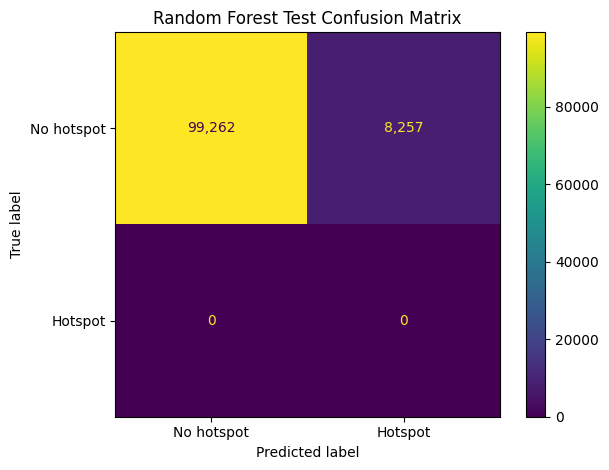

In [77]:
confusion = confusion_matrix(
    y_test,
    test_prediction
)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "No hotspot",
        "Hotspot"
    ]
)

cm_display.plot(
    values_format=",d"
)

plt.title(
    "Random Forest Test Confusion Matrix"
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = (
    RESULTS_FOLDER
    / "test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

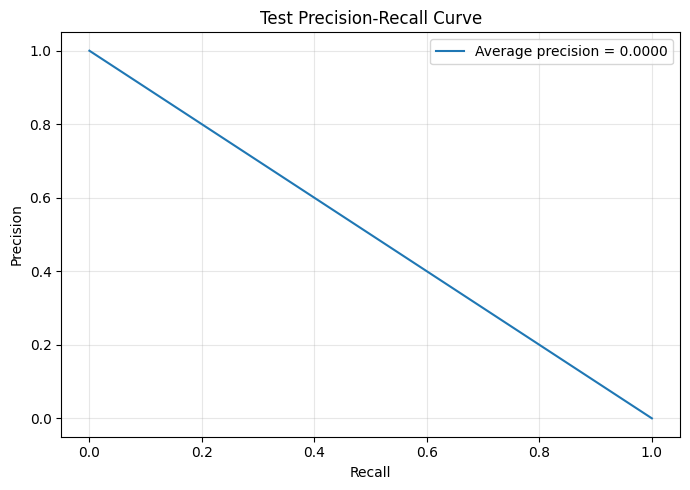

In [64]:
test_precision, test_recall, _ = (
    precision_recall_curve(
        y_test,
        test_probability
    )
)

test_average_precision = (
    average_precision_score(
        y_test,
        test_probability
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    test_recall,
    test_precision,
    label=(
        f"Average precision = "
        f"{test_average_precision:.4f}"
    )
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

PR_CURVE_PATH = (
    RESULTS_FOLDER
    / "test_precision_recall_curve.png"
)

plt.savefig(
    PR_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
feature_importance = (
    pd.DataFrame({
        "feature": MODEL_FEATURES,
        "importance": (
            random_forest.feature_importances_
        )
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance.head(15)

,feature,importance
0,month,0.110755
1,relative_humidity,0.102368
2,day_of_year_sin,0.078043
3,humidity_mean_3d,0.069546
4,humidity_mean_7d,0.052111
5,temperature_max_3d,0.046747
6,temperature_max_7d,0.043837
7,temperature_max_c,0.042539
8,precipitation_mm,0.037713
9,day_of_year_cos,0.037248


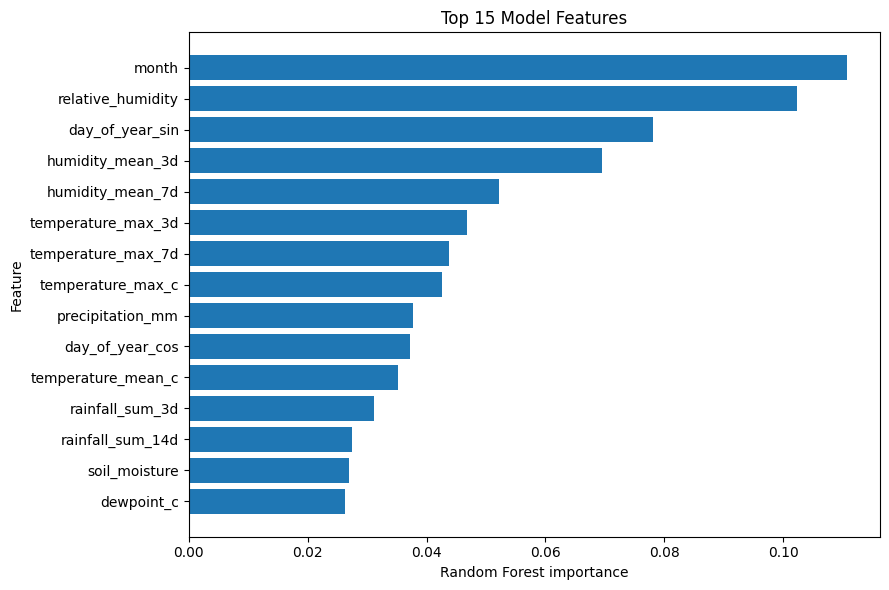

In [66]:
top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Top 15 Model Features")
plt.tight_layout()

FEATURE_IMPORTANCE_PLOT_PATH = (
    RESULTS_FOLDER
    / "feature_importance_top15.png"
)

plt.savefig(
    FEATURE_IMPORTANCE_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
FEATURE_IMPORTANCE_PATH = (
    RESULTS_FOLDER
    / "feature_importance.csv"
)

feature_importance.to_csv(
    FEATURE_IMPORTANCE_PATH,
    index=False
)

In [68]:
MODEL_PATH = (
    MODEL_FOLDER
    / "wildfire_next_day_random_forest.joblib"
)

model_bundle = {
    "model": random_forest,

    "feature_columns": MODEL_FEATURES,

    "decision_threshold": best_threshold,

    "target": "fire_next_day",

    "training_period": {
        "start": str(
            wildfire.loc[
                train_mask,
                "date"
            ].min().date()
        ),
        "end": str(
            wildfire.loc[
                train_mask,
                "date"
            ].max().date()
        )
    },

    "validation_period": {
        "start": str(
            wildfire.loc[
                validation_mask,
                "date"
            ].min().date()
        ),
        "end": str(
            wildfire.loc[
                validation_mask,
                "date"
            ].max().date()
        )
    },

    "test_period": {
        "start": str(
            wildfire.loc[
                test_mask,
                "date"
            ].min().date()
        ),
        "end": str(
            wildfire.loc[
                test_mask,
                "date"
            ].max().date()
        )
    },

    "application": (
        "Estimate the probability of a NASA FIRMS "
        "active-fire hotspot in an ERA5-Land grid "
        "cell on the following day."
    )
}

joblib.dump(
    model_bundle,
    MODEL_PATH
)

print("Saved model:", MODEL_PATH)

Saved model: /content/drive/MyDrive/Wildfire_ML_Project/models/wildfire_next_day_random_forest.joblib


In [69]:
METRICS_PATH = (
    RESULTS_FOLDER
    / "model_metrics.json"
)

all_metrics = {
    "validation_default": (
        validation_default_metrics
    ),

    "validation_tuned": (
        validation_tuned_metrics
    ),

    "test": test_metrics
}

with open(
    METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        all_metrics,
        file,
        indent=2
    )

print("Saved metrics:", METRICS_PATH)

Saved metrics: /content/drive/MyDrive/Wildfire_ML_Project/results/model_metrics.json


In [70]:
loaded_bundle = joblib.load(
    MODEL_PATH
)

print(
    "Loaded feature count:",
    len(
        loaded_bundle[
            "feature_columns"
        ]
    )
)

print(
    "Loaded threshold:",
    loaded_bundle[
        "decision_threshold"
    ]
)

print(
    "Application:",
    loaded_bundle[
        "application"
    ]
)

Loaded feature count: 29
Loaded threshold: 0.6174135162595815
Application: Estimate the probability of a NASA FIRMS active-fire hotspot in an ERA5-Land grid cell on the following day.


## 13. Model Performance Review

The trained model is evaluated on the untouched chronological test period.
Because hotspot observations are rare, the analysis prioritises average
precision, recall, precision, F1-score and the confusion matrix rather than
overall accuracy.

In [71]:
# Validation threshold comparison
validation_comparison[
    [
        "setting",
        "threshold",
        "precision",
        "recall",
        "f1_score",
        "average_precision",
        "roc_auc",
        "predicted_positive",
        "actual_positive"
    ]
]

,setting,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,Default threshold,0.500000,0.013075,0.243346,0.024816,0.010083,0.76774,4895,263
1,Validation-tuned threshold,0.617414,0.017808,0.098859,0.030180,0.010083,0.76774,1460,263


In [72]:
# Final test metrics
test_results = pd.DataFrame(
    [test_metrics]
)

test_results

,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,0.617414,0.0,0.0,0.0,0.0,NaN,8257,0


In [73]:
# Final test metrics
test_results = pd.DataFrame(
    [test_metrics]
)

test_results

,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,0.617414,0.0,0.0,0.0,0.0,NaN,8257,0


In [74]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_prediction
).ravel()

test_positive_rate = y_test.mean()

evaluation_summary = pd.DataFrame({
    "metric": [
        "Test rows",
        "Actual hotspot rows",
        "Baseline positive rate",
        "Average precision",
        "ROC-AUC",
        "Precision",
        "Recall",
        "F1-score",
        "True positives",
        "False positives",
        "False negatives",
        "True negatives",
        "Decision threshold"
    ],
    "value": [
        len(y_test),
        int(y_test.sum()),
        test_positive_rate,
        test_metrics["average_precision"],
        test_metrics["roc_auc"],
        test_metrics["precision"],
        test_metrics["recall"],
        test_metrics["f1_score"],
        int(tp),
        int(fp),
        int(fn),
        int(tn),
        best_threshold
    ]
})

evaluation_summary

,metric,value
0,Test rows,107519.000000
1,Actual hotspot rows,0.000000
2,Baseline positive rate,0.000000
3,Average precision,0.000000
4,ROC-AUC,NaN
5,Precision,0.000000
6,Recall,0.000000
7,F1-score,0.000000
8,True positives,0.000000
9,False positives,8257.000000


In [75]:
ap_improvement_ratio = (
    test_metrics["average_precision"]
    / test_positive_rate
)

print(
    "Test positive rate:",
    round(test_positive_rate, 6)
)

print(
    "Model average precision:",
    round(
        test_metrics["average_precision"],
        6
    )
)

print(
    "Average-precision improvement over baseline:",
    round(ap_improvement_ratio, 2),
    "times"
)

Test positive rate: 0.0
Model average precision: 0.0
Average-precision improvement over baseline: nan times


In [79]:
from IPython.display import display as show_table

TARGET_RECALL = 0.80

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probability
    )
)

valid_indices = np.where(
    recall_values[:-1] >= TARGET_RECALL
)[0]

if len(valid_indices) > 0:

    selected_index = valid_indices[
        np.argmax(
            precision_values[:-1][valid_indices]
        )
    ]

    recall_priority_threshold = float(
        thresholds[selected_index]
    )

    print(
        "Recall-priority threshold:",
        round(recall_priority_threshold, 4)
    )

    recall_priority_validation = evaluate_predictions(
        y_validation,
        validation_probability,
        recall_priority_threshold
    )

    recall_priority_test = evaluate_predictions(
        y_test,
        test_probability,
        recall_priority_threshold
    )

    recall_priority_comparison = pd.DataFrame([
        {
            "dataset": "Validation",
            **recall_priority_validation
        },
        {
            "dataset": "Test",
            **recall_priority_test
        }
    ])

    show_table(recall_priority_comparison)

else:
    print(
        "No validation threshold achieved the target recall."
    )

Recall-priority threshold: 0.1931


,dataset,threshold,precision,recall,f1_score,average_precision,roc_auc,predicted_positive,actual_positive
0,Validation,0.193098,0.006535,0.802281,0.012965,0.010083,0.76774,32286,263
1,Test,0.193098,0.000000,0.000000,0.000000,0.000000,NaN,51353,0


In [80]:
threshold_comparison = pd.DataFrame([
    {
        "threshold_strategy": "Best validation F1",
        "threshold": best_threshold,
        "test_precision": test_metrics["precision"],
        "test_recall": test_metrics["recall"],
        "test_f1": test_metrics["f1_score"],
        "test_predicted_positive": test_metrics["predicted_positive"]
    },
    {
        "threshold_strategy": "80% validation recall",
        "threshold": recall_priority_threshold,
        "test_precision": recall_priority_test["precision"],
        "test_recall": recall_priority_test["recall"],
        "test_f1": recall_priority_test["f1_score"],
        "test_predicted_positive": recall_priority_test[
            "predicted_positive"
        ]
    }
])

show_table(threshold_comparison)

,threshold_strategy,threshold,test_precision,test_recall,test_f1,test_predicted_positive
0,Best validation F1,0.617414,0.0,0.0,0.0,8257
1,80% validation recall,0.193098,0.0,0.0,0.0,51353


In [81]:
loaded_bundle = joblib.load(
    MODEL_PATH
)

sample_features = X_test.iloc[[0]]

memory_probability = (
    random_forest.predict_proba(
        sample_features
    )[0, 1]
)

saved_probability = (
    loaded_bundle["model"]
    .predict_proba(
        sample_features[
            loaded_bundle["feature_columns"]
        ]
    )[0, 1]
)

print(
    "In-memory probability:",
    memory_probability
)

print(
    "Saved-model probability:",
    saved_probability
)

assert np.isclose(
    memory_probability,
    saved_probability
)

print("Saved model verification passed.")

In-memory probability: 0.2525742165321044
Saved-model probability: 0.2525742165321044
Saved model verification passed.


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 120 out of 120 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 120 out of 120 | elapsed:    0.0s finished


## 14. Operating Threshold Configuration

Two probability thresholds were evaluated:

- The F1-optimised threshold balances precision and recall.
- The recall-priority threshold places greater importance on detecting
  hotspot events, potentially at the cost of additional false alerts.

The F1-optimised threshold is retained as the primary research threshold.
The recall-priority threshold is saved as an alternative operating mode for
early-warning applications.

In [82]:
PRIMARY_THRESHOLD = float(best_threshold)

ALTERNATIVE_THRESHOLD = float(
    recall_priority_threshold
)

print(
    "Primary F1 threshold:",
    round(PRIMARY_THRESHOLD, 4)
)

print(
    "Alternative recall-priority threshold:",
    round(ALTERNATIVE_THRESHOLD, 4)
)

Primary F1 threshold: 0.6174
Alternative recall-priority threshold: 0.1931


In [83]:
loaded_bundle = joblib.load(
    MODEL_PATH
)

loaded_bundle[
    "primary_decision_threshold"
] = PRIMARY_THRESHOLD

loaded_bundle[
    "recall_priority_threshold"
] = ALTERNATIVE_THRESHOLD

loaded_bundle[
    "threshold_description"
] = {
    "primary": (
        "Threshold selected by maximising "
        "validation F1-score."
    ),
    "recall_priority": (
        "Threshold selected to target at least "
        "80% validation recall."
    )
}

joblib.dump(
    loaded_bundle,
    MODEL_PATH
)

print(
    "Updated model bundle saved:",
    MODEL_PATH
)

Updated model bundle saved: /content/drive/MyDrive/Wildfire_ML_Project/models/wildfire_next_day_random_forest.joblib


In [84]:
updated_bundle = joblib.load(
    MODEL_PATH
)

print(
    "Primary threshold:",
    updated_bundle[
        "primary_decision_threshold"
    ]
)

print(
    "Recall-priority threshold:",
    updated_bundle[
        "recall_priority_threshold"
    ]
)

Primary threshold: 0.6174135162595815
Recall-priority threshold: 0.1930983110818511


## 15. Spatial Wildfire-Risk Prediction

The trained model is applied to every ERA5-Land grid cell for the latest
available modelling date.

Each grid cell receives:

- A next-day hotspot probability
- A binary alert prediction
- An operational risk category

This produces a spatial wildfire-risk surface across Nepal.

In [85]:
LATEST_MODELLING_DATE = wildfire[
    "date"
].max()

latest_day = (
    wildfire.loc[
        wildfire["date"]
        == LATEST_MODELLING_DATE
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    "Prediction input date:",
    LATEST_MODELLING_DATE
)

print(
    "Prediction target date:",
    LATEST_MODELLING_DATE
    + pd.Timedelta(days=1)
)

print(
    "Grid cells:",
    len(latest_day)
)

Prediction input date: 2026-05-18 00:00:00
Prediction target date: 2026-05-19 00:00:00
Grid cells: 1361


In [86]:
model_bundle = joblib.load(
    MODEL_PATH
)

saved_model = model_bundle["model"]

saved_features = model_bundle[
    "feature_columns"
]

operating_threshold = model_bundle[
    "primary_decision_threshold"
]

In [87]:
missing_features = [
    feature
    for feature in saved_features
    if feature not in latest_day.columns
]

assert not missing_features, (
    f"Missing model features: {missing_features}"
)

print(
    "All required model features are available."
)

All required model features are available.


In [88]:
latest_day[
    "hotspot_probability"
] = saved_model.predict_proba(
    latest_day[saved_features]
)[:, 1]

latest_day[
    "predicted_hotspot"
] = (
    latest_day[
        "hotspot_probability"
    ] >= operating_threshold
).astype("int8")

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 120 out of 120 | elapsed:    0.0s finished


In [89]:
print(
    "Probability range:",
    latest_day[
        "hotspot_probability"
    ].min(),
    "to",
    latest_day[
        "hotspot_probability"
    ].max()
)

print(
    "Predicted hotspot grid cells:",
    latest_day[
        "predicted_hotspot"
    ].sum()
)

Probability range: 0.0 to 0.47736033458328764
Predicted hotspot grid cells: 0


In [90]:
def assign_risk_level(
    probability,
    threshold
):
    if probability >= threshold:
        return "Very High"

    if probability >= threshold * 0.75:
        return "High"

    if probability >= threshold * 0.40:
        return "Moderate"

    return "Low"

In [91]:
latest_day["risk_level"] = [
    assign_risk_level(
        probability,
        operating_threshold
    )
    for probability in latest_day[
        "hotspot_probability"
    ]
]

In [92]:
risk_level_summary = (
    latest_day[
        "risk_level"
    ]
    .value_counts()
    .reindex(
        [
            "Low",
            "Moderate",
            "High",
            "Very High"
        ],
        fill_value=0
    )
    .rename_axis("risk_level")
    .reset_index(name="grid_cells")
)

show_table(risk_level_summary)

,risk_level,grid_cells
0,Low,1194
1,Moderate,166
2,High,1
3,Very High,0


In [93]:
spatial_risk_predictions = (
    latest_day[
        [
            "date",
            "latitude",
            "longitude",
            "hotspot_probability",
            "predicted_hotspot",
            "risk_level"
        ]
    ]
    .sort_values(
        "hotspot_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

In [94]:
show_table(
    spatial_risk_predictions.head(20)
)

,date,latitude,longitude,hotspot_probability,predicted_hotspot,risk_level
0,2026-05-18,29.599723,80.501192,0.477360,0,High
1,2026-05-18,29.499723,80.401191,0.442529,0,Moderate
2,2026-05-18,29.199722,81.001194,0.432091,0,Moderate
3,2026-05-18,29.199722,81.101195,0.430184,0,Moderate
4,2026-05-18,29.699724,80.501192,0.427298,0,Moderate
5,2026-05-18,29.599723,80.601192,0.423143,0,Moderate
6,2026-05-18,29.699724,80.601192,0.422392,0,Moderate
7,2026-05-18,29.099721,80.401191,0.418913,0,Moderate
8,2026-05-18,28.999721,80.601192,0.412955,0,Moderate
9,2026-05-18,28.999721,80.501192,0.412534,0,Moderate


In [95]:
SPATIAL_PREDICTIONS_PATH = (
    RESULTS_FOLDER
    / "latest_spatial_risk_predictions.csv"
)

spatial_risk_predictions.to_csv(
    SPATIAL_PREDICTIONS_PATH,
    index=False
)

print(
    "Saved spatial predictions:",
    SPATIAL_PREDICTIONS_PATH
)

Saved spatial predictions: /content/drive/MyDrive/Wildfire_ML_Project/results/latest_spatial_risk_predictions.csv


In [96]:
SPATIAL_PREDICTIONS_PARQUET_PATH = (
    RESULTS_FOLDER
    / "latest_spatial_risk_predictions.parquet"
)

spatial_risk_predictions.to_parquet(
    SPATIAL_PREDICTIONS_PARQUET_PATH,
    index=False
)

print(
    "Saved Parquet predictions:",
    SPATIAL_PREDICTIONS_PARQUET_PATH
)

Saved Parquet predictions: /content/drive/MyDrive/Wildfire_ML_Project/results/latest_spatial_risk_predictions.parquet


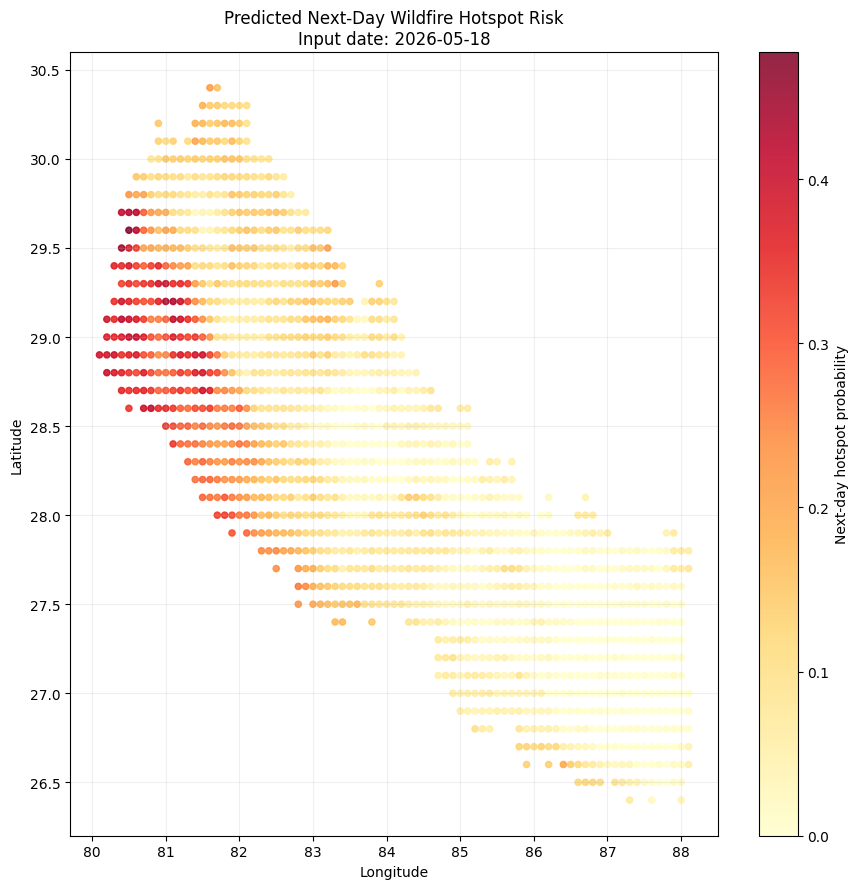

In [97]:
plt.figure(figsize=(9, 9))

scatter = plt.scatter(
    latest_day["longitude"],
    latest_day["latitude"],
    c=latest_day[
        "hotspot_probability"
    ],
    s=20,
    cmap="YlOrRd",
    alpha=0.85
)

plt.colorbar(
    scatter,
    label="Next-day hotspot probability"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Predicted Next-Day Wildfire Hotspot Risk\n"
    f"Input date: "
    f"{LATEST_MODELLING_DATE.date()}"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

RISK_MAP_PATH = (
    RESULTS_FOLDER
    / "latest_wildfire_risk_map.png"
)

plt.savefig(
    RISK_MAP_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [98]:
TOP_N = 20

highest_risk_cells = (
    spatial_risk_predictions
    .head(TOP_N)
    .copy()
)

show_table(
    highest_risk_cells
)

,date,latitude,longitude,hotspot_probability,predicted_hotspot,risk_level
0,2026-05-18,29.599723,80.501192,0.477360,0,High
1,2026-05-18,29.499723,80.401191,0.442529,0,Moderate
2,2026-05-18,29.199722,81.001194,0.432091,0,Moderate
3,2026-05-18,29.199722,81.101195,0.430184,0,Moderate
4,2026-05-18,29.699724,80.501192,0.427298,0,Moderate
5,2026-05-18,29.599723,80.601192,0.423143,0,Moderate
6,2026-05-18,29.699724,80.601192,0.422392,0,Moderate
7,2026-05-18,29.099721,80.401191,0.418913,0,Moderate
8,2026-05-18,28.999721,80.601192,0.412955,0,Moderate
9,2026-05-18,28.999721,80.501192,0.412534,0,Moderate


In [99]:
print(
    "Prediction date:",
    LATEST_MODELLING_DATE.date()
)

print(
    "Forecast date:",
    (
        LATEST_MODELLING_DATE
        + pd.Timedelta(days=1)
    ).date()
)

print(
    "Total grid cells:",
    len(spatial_risk_predictions)
)

print(
    "Alerted grid cells:",
    spatial_risk_predictions[
        "predicted_hotspot"
    ].sum()
)

print(
    "Maximum probability:",
    round(
        spatial_risk_predictions[
            "hotspot_probability"
        ].max(),
        4
    )
)

Prediction date: 2026-05-18
Forecast date: 2026-05-19
Total grid cells: 1361
Alerted grid cells: 0
Maximum probability: 0.4774
